# 🤖 VLM: 시각-언어 모델 이해하기

**실행 환경:** Google Colab (GPU 권장)

---

## 📌 이 노트북에서 배울 내용

| 순서 | 내용 |
|------|------|
| 1 | VLM이란 무엇인가? (이론) |
| 2 | CLIP: 이미지와 텍스트를 연결하는 핵심 기술 |
| 3 | 실습 1 - 이미지 분류 (zero-shot) |
| 4 | 실습 2 - 이미지 캡셔닝 (BLIP) |
| 5 | 실습 3 - 이미지로 질문하기 (VQA) |
| 6 | 최신 VLM 트렌드 |

---

## 🔑 이 노트북의 핵심 질문

> **"AI가 이미지를 보고 사람처럼 이해하려면 무엇이 필요할까?"**

사람은 고양이 사진을 보면 자연스럽게 "귀여운 고양이네"라고 말할 수 있습니다.
VLM은 AI가 이미지와 언어를 **동시에** 이해할 수 있게 만든 기술입니다.

---

# 1️⃣ VLM (Vision-Language Model) 이란?

## 📖 이론

### 이전 AI의 한계

```
기존 이미지 AI (CNN):  사진 → [AI] → "고양이" (단순 분류)
기존 언어 AI (GPT):   텍스트 → [AI] → 텍스트 (이미지 이해 불가)
```

### VLM의 혁신

```
VLM:  사진 + "이 사진에서 고양이는 몇 마리야?" → [VLM] → "두 마리입니다"
      이미지와 텍스트를 함께 이해!
```

### VLM = 눈 + 뇌 + 입

| 구성 요소 | 역할 | AI에서의 역할 |
|-----------|------|---------------|
| **시각 인코더** | 눈 👁 | 이미지를 숫자로 변환 |
| **언어 인코더** | 뇌 🧠 | 텍스트를 숫자로 변환 |
| **연결 모듈** | 이해 💡 | 이미지와 텍스트를 같은 공간에 매핑 |
| **언어 디코더** | 입 💬 | 답변 텍스트 생성 |

### VLM이 가능한 것들

- 📷 **이미지 캡셔닝**: 사진을 보고 설명문 생성
- ❓ **시각적 질의응답(VQA)**: 사진에 대한 질문 답변
- 🔍 **이미지 검색**: 텍스트로 이미지 찾기
- 🎨 **텍스트→이미지**: 텍스트로 이미지 생성
- 📝 **OCR + 이해**: 문서 사진을 읽고 내용 파악

### 대표적인 VLM들

| 모델 | 개발사 | 특징 |
|------|--------|------|
| **CLIP** | OpenAI (2021) | 이미지-텍스트 연결의 기초 기술 |
| **BLIP** | Salesforce (2022) | 이미지 캡셔닝, VQA |
| **GPT-4V** | OpenAI (2023) | ChatGPT가 사진을 이해 |
| **LLaVA** | 위스콘신대 (2023) | 오픈소스 VLM |
| **Gemini** | Google (2023) | 텍스트+이미지+음성 통합 |

In [2]:
# 환경 설정
print('필요한 라이브러리 설치 중...')
!pip install transformers torch torchvision pillow requests matplotlib -q

import torch
import requests
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from PIL import Image
from io import BytesIO

!apt-get install -y fonts-nanum > /dev/null 2>&1

# 설치된 나눔 폰트 경로를 직접 찾아서 등록
import glob
import matplotlib.font_manager as fm
nanum_paths = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
if nanum_paths:
    fm.fontManager.addfont(nanum_paths[0])
    plt.rcParams['font.family'] = 'NanumGothic'
    print('한글 폰트(NanumGothic) 설정 완료 ✅')
else:
    # 대안: NanumBarunGothic 시도
    alt_paths = glob.glob('/usr/share/fonts/truetype/nanum/*.ttf')
    if alt_paths:
        fm.fontManager.addfont(alt_paths[0])
        font_name = fm.FontProperties(fname=alt_paths[0]).get_name()
        plt.rcParams['font.family'] = font_name
        print(f'한글 폰트({font_name}) 설정 완료 ✅')
    else:
        print('⚠️ 한글 폰트를 찾지 못했습니다. 영어로 표시됩니다.')

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 중인 장치: {device}')
print('환경 설정 완료! ✅')

필요한 라이브러리 설치 중...
한글 폰트(NanumGothic) 설정 완료 ✅
사용 중인 장치: cuda
환경 설정 완료! ✅


고양이 로드 성공 ✅
도시 풍경 로드 성공 ✅
음식 로드 성공 ✅


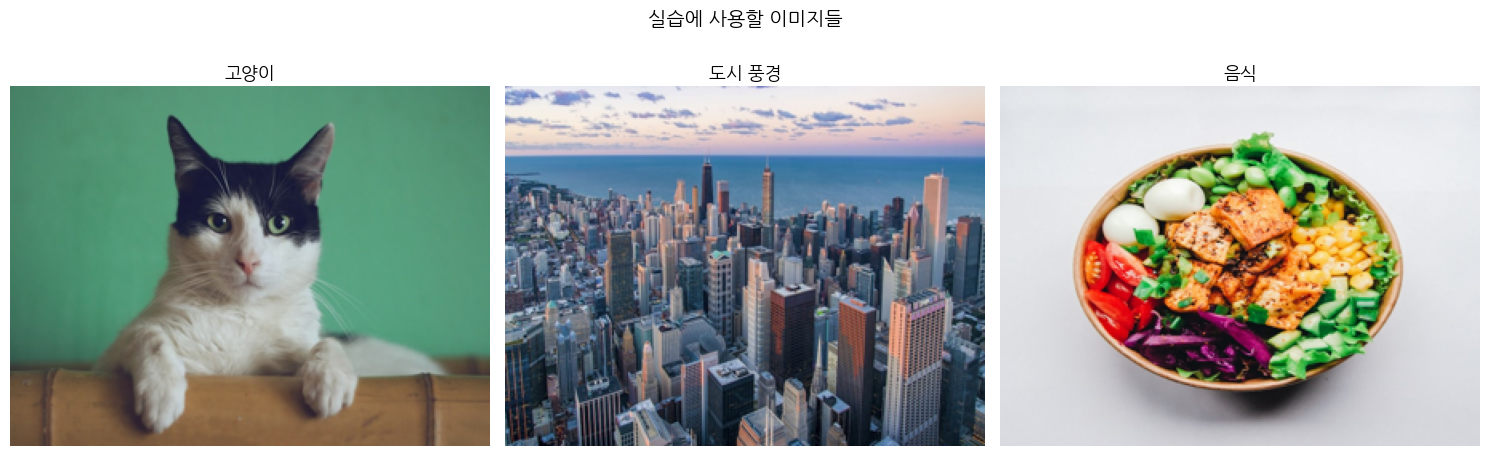


총 3개 이미지 준비 완료! ✅


In [3]:
# 실습에 사용할 이미지 준비
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

def load_image_from_url(url):
    """URL에서 이미지를 불러오는 함수 (헤더 포함)"""
    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

# 안정적인 공개 이미지 (Unsplash CDN)
sample_images = {
    '고양이': 'https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=640&q=80',
    '도시 풍경': 'https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=640&q=80',
    '음식': 'https://images.unsplash.com/photo-1546069901-ba9599a7e63c?w=640&q=80',
}

# 이미지 로드 및 표시
images = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, url) in enumerate(sample_images.items()):
    try:
        img = load_image_from_url(url)
        img_resized = img.resize((300, 225))
        images[name] = img_resized
        axes[idx].imshow(img_resized)
        axes[idx].set_title(name, fontsize=13)
        axes[idx].axis('off')
        print(f'{name} 로드 성공 ✅')
    except Exception as e:
        print(f'{name} 로드 실패: {e}')
        axes[idx].text(0.5, 0.5, '이미지 로드 실패\nURL을 확인하세요',
                      ha='center', va='center', fontsize=10)
        axes[idx].axis('off')

plt.suptitle('실습에 사용할 이미지들', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n총 {len(images)}개 이미지 준비 완료! ✅')

---

# 2️⃣ CLIP: 이미지와 텍스트를 연결하는 기술

## 📖 이론

### CLIP (Contrastive Language-Image Pre-training)

**2021년 OpenAI가 발표**, VLM의 핵심 기반 기술

```
이미지 → [이미지 인코더] → 이미지 벡터 ─┐
                                        ├── 유사도 계산 → 매칭!
텍스트 → [텍스트 인코더] → 텍스트 벡터 ─┘
```

### CLIP의 학습 방법

**4억 개의 이미지-텍스트 쌍**으로 학습:
- "고양이 사진" + "a photo of a cat" → 유사하게!
- "고양이 사진" + "a photo of a dog" → 달라야!

### 핵심 개념: 임베딩 공간



이미지와 텍스트가 **같은 공간**에 배치되어 비교 가능해짐!

In [4]:
# CLIP 모델 로드
print('CLIP 모델 로드 중...')
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model.eval()
print('CLIP 모델 로드 완료! ✅')
total_params = sum(p.numel() for p in clip_model.parameters())
print(f'모델 크기: {total_params/1e6:.0f}M 파라미터')

CLIP 모델 로드 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP 모델 로드 완료! ✅
모델 크기: 151M 파라미터


---

# 3️⃣ 실습 1: Zero-Shot 이미지 분류

## 📖 개념

### Zero-Shot이란?

**한 번도 학습하지 않은 카테고리**도 분류할 수 있는 능력!

```
기존 방식: 고양이 1만 장 → 학습 → "고양이" 분류 가능
Zero-Shot: 고양이 학습 없이 → "이 이미지가 고양이같나요?" → 답변 가능!
```

**비유:** 전문가에게 처음 보는 동물 사진을 보여주면 이름을 알려줘도 알아볼 수 있는 것처럼,
CLIP은 텍스트 설명만으로 이미지를 분류할 수 있습니다.

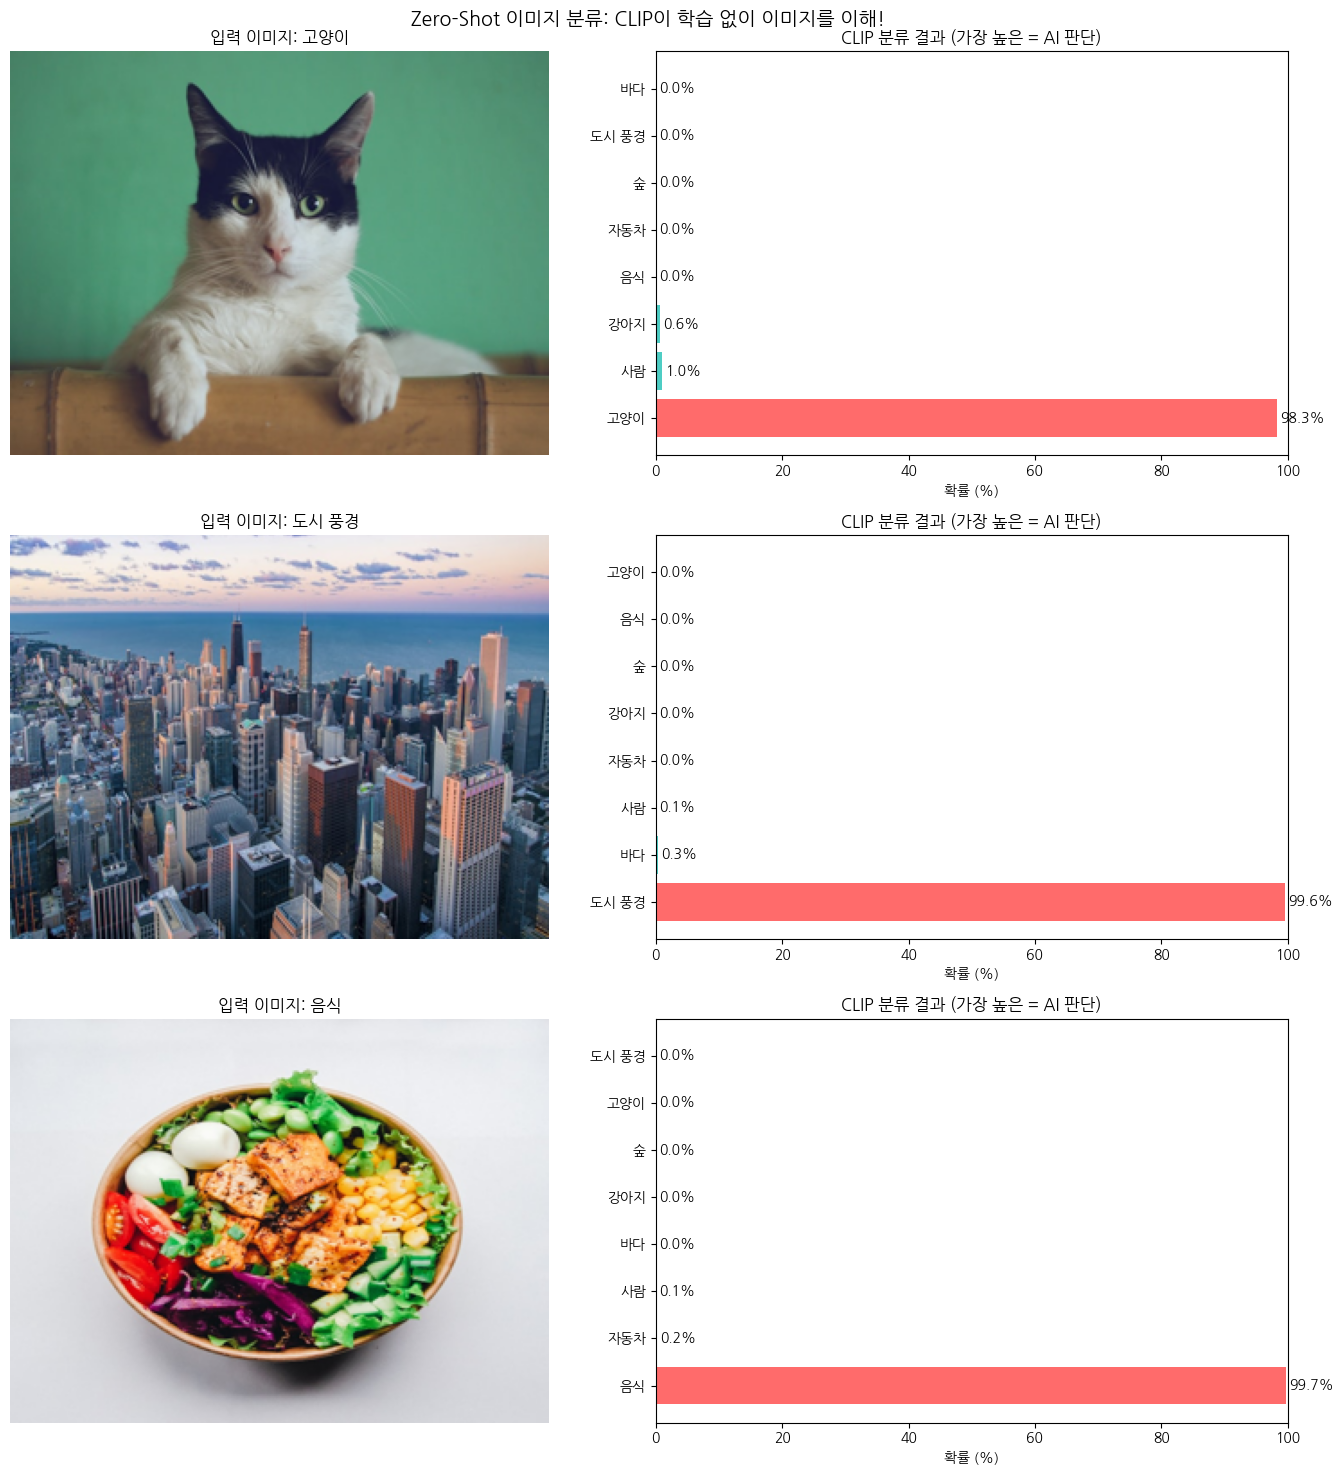

✅ CLIP은 학습에 없던 카테고리도 텍스트 설명만으로 분류합니다!


In [5]:
# Zero-Shot 이미지 분류 실습

def classify_image(image, candidate_labels):
    """
    CLIP으로 이미지를 분류합니다.
    candidate_labels: 후보 카테고리 목록 (영어)
    """
    # 텍스트 후보를 자연스러운 문장으로 변환
    texts = [f"a photo of {label}" for label in candidate_labels]

    # CLIP 입력 형식으로 변환
    inputs = clip_processor(
        text=texts,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    # 이미지-텍스트 유사도 계산
    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)[0]  # 확률로 변환

    return [(label, prob.item()) for label, prob in zip(candidate_labels, probs)]

# 분류 후보 카테고리
categories = [
    "a cat", "a dog", "a city skyline", "food",
    "a forest", "an ocean", "a person", "a car"
]
categories_ko = ["고양이", "강아지", "도시 풍경", "음식",
                 "숲", "바다", "사람", "자동차"]

# 각 이미지에 대해 분류 실행
fig, axes = plt.subplots(len(images), 2, figsize=(14, 5*len(images)))
if len(images) == 1:
    axes = [axes]

for idx, (img_name, img) in enumerate(images.items()):
    results = classify_image(img, categories)
    results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

    # 이미지 표시
    axes[idx][0].imshow(img)
    axes[idx][0].set_title(f'입력 이미지: {img_name}', fontsize=12)
    axes[idx][0].axis('off')

    # 분류 결과 막대 그래프
    labels_sorted = [categories_ko[categories.index(r[0])] for r in results_sorted]
    probs_sorted = [r[1] * 100 for r in results_sorted]
    colors = ['#FF6B6B' if i == 0 else '#4ECDC4' for i in range(len(labels_sorted))]

    bars = axes[idx][1].barh(labels_sorted, probs_sorted, color=colors)
    axes[idx][1].set_xlabel('확률 (%)')
    axes[idx][1].set_title(f'CLIP 분류 결과 (가장 높은 = AI 판단)', fontsize=12)
    axes[idx][1].set_xlim(0, 100)

    for bar, prob in zip(bars, probs_sorted):
        axes[idx][1].text(prob + 0.5, bar.get_y() + bar.get_height()/2,
                         f'{prob:.1f}%', va='center', fontsize=10)

plt.suptitle('Zero-Shot 이미지 분류: CLIP이 학습 없이 이미지를 이해!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ CLIP은 학습에 없던 카테고리도 텍스트 설명만으로 분류합니다!')

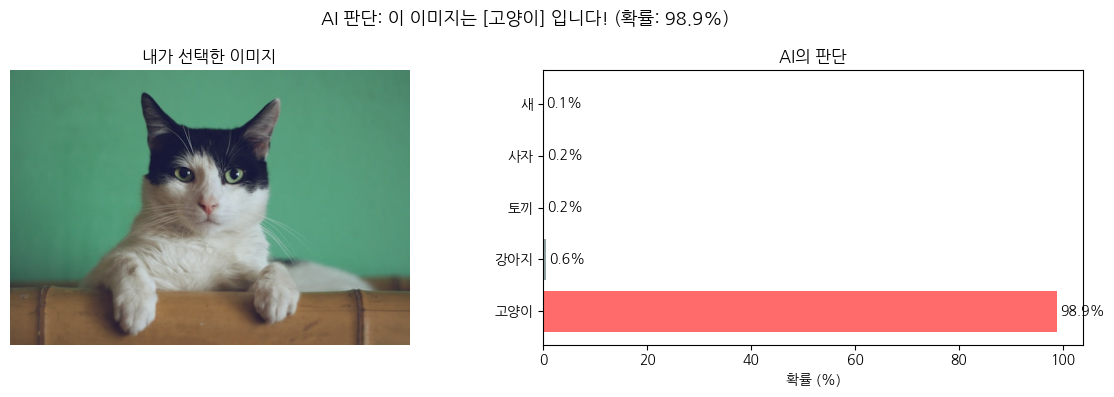

In [6]:
# 직접 해보기: 나만의 이미지 분류
# ✏️ 아래 URL과 카테고리를 원하는 것으로 바꿔보세요!

my_image_url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=640&q=80"
my_categories = ["a cat", "a dog", "a bird", "a rabbit", "a lion"]
my_categories_ko = ["고양이", "강아지", "새", "토끼", "사자"]

# 분류 실행
my_image = load_image_from_url(my_image_url)
results = classify_image(my_image, my_categories)
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(my_image)
ax1.set_title('내가 선택한 이미지', fontsize=12)
ax1.axis('off')

labels_sorted = [my_categories_ko[my_categories.index(r[0])] for r in results_sorted]
probs_sorted = [r[1] * 100 for r in results_sorted]
colors = ['#FF6B6B' if i == 0 else '#95A5A6' for i in range(len(labels_sorted))]

bars = ax2.barh(labels_sorted, probs_sorted, color=colors)
ax2.set_xlabel('확률 (%)')
ax2.set_title('AI의 판단', fontsize=12)
for bar, prob in zip(bars, probs_sorted):
    ax2.text(prob + 0.5, bar.get_y() + bar.get_height()/2,
             f'{prob:.1f}%', va='center')

best = results_sorted[0]
best_ko = my_categories_ko[my_categories.index(best[0])]
plt.suptitle(f'AI 판단: 이 이미지는 [{best_ko}] 입니다! (확률: {best[1]*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

# 4️⃣ 실습 2: 이미지 캡셔닝 (BLIP)

## 📖 개념

### 이미지 캡셔닝이란?

이미지를 보고 **자동으로 설명 문장을 생성**하는 기술

```
입력: [사진]
출력: "a cat sitting on a red cushion near a window"
      (창가의 빨간 쿠션 위에 앉아있는 고양이)
```

### BLIP 모델

**Bootstrapping Language-Image Pre-training**
- Salesforce가 2022년 발표
- CLIP보다 이미지 설명 생성 능력이 뛰어남
- 이미지 캡셔닝 + VQA 모두 가능

### 활용 사례
- 시각장애인을 위한 이미지 설명
- 사진 자동 태그 생성
- 이미지 검색 시스템

In [7]:
# BLIP 모델로 이미지 캡셔닝
print('BLIP 모델 로드 중...')
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)
blip_model.eval()
print('BLIP 모델 로드 완료! ✅')

BLIP 모델 로드 중...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP 모델 로드 완료! ✅


이미지 캡션 생성 중...

[고양이]
  AI 설명 (영어): a black and white cat sitting on top of a box

[도시 풍경]
  AI 설명 (영어): a view of the chicago skyline at sunset

[음식]
  AI 설명 (영어): a bowl of salad with chicken and vegetables


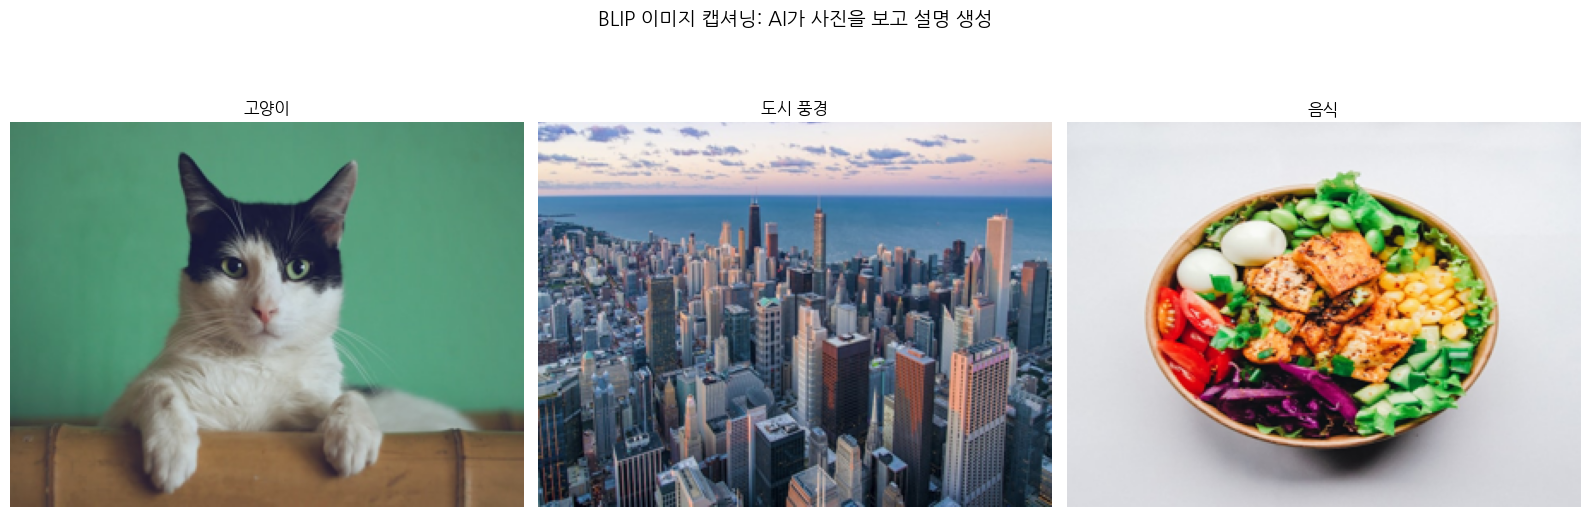


✅ AI가 이미지를 보고 영어로 설명을 자동 생성합니다!


In [8]:
def generate_caption(image, max_length=50):
    """이미지를 보고 영어 설명을 생성합니다"""
    inputs = blip_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        output = blip_model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,  # 더 좋은 문장 탐색
            early_stopping=True
        )
    caption = blip_processor.decode(output[0], skip_special_tokens=True)
    return caption

# 각 이미지에 캡션 생성
fig, axes = plt.subplots(1, len(images), figsize=(16, 6))
if len(images) == 1:
    axes = [axes]

caption_translations = {
    '고양이': '(한국어 번역: AI가 생성한 고양이 설명)',
    '도시 풍경': '(한국어 번역: AI가 생성한 도시 설명)',
    '음식': '(한국어 번역: AI가 생성한 음식 설명)',
}

print('이미지 캡션 생성 중...')
for idx, (img_name, img) in enumerate(images.items()):
    caption = generate_caption(img)
    print(f'\n[{img_name}]')
    print(f'  AI 설명 (영어): {caption}')

    axes[idx].imshow(img)
    # 캡션을 이미지 아래에 표시
    axes[idx].set_title(img_name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f'AI 설명:\n"{caption}"', fontsize=9, wrap=True)
    axes[idx].axis('off')

plt.suptitle('BLIP 이미지 캡셔닝: AI가 사진을 보고 설명 생성',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n✅ AI가 이미지를 보고 영어로 설명을 자동 생성합니다!')

---

# 5️⃣ 실습 3: 시각적 질의응답 (VQA)

## 📖 개념

### VQA (Visual Question Answering)

이미지를 보고 자연어 질문에 답변하는 기술!

```
입력: [고양이 사진] + "What color is the cat?"
출력: "orange and white"

입력: [음식 사진] + "Is this food hot or cold?"
출력: "hot"
```

### 활용 사례
- 의료 영상 분석 ("이 X-ray에서 이상한 부분이 있나요?")
- 위성 사진 분석 ("이 지역에 건물이 있나요?")
- 제품 검수 ("이 제품에 불량이 있나요?")

In [9]:
# BLIP으로 VQA (이미지 + 질문 → 답변)
from transformers import BlipForQuestionAnswering

print('VQA 모델 로드 중...')
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
).to(device)
vqa_model.eval()
print('VQA 모델 로드 완료! ✅')

VQA 모델 로드 중...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


VQA 모델 로드 완료! ✅


VQA 실습: AI에게 이미지를 보고 질문에 답하게 합니다!

📷 [고양이] 이미지에 대한 질의응답:
  Q: 어떤 동물인가요?
  A (영어): cat

  Q: 색깔이 무엇인가요?
  A (영어): white and black

  Q: 실내인가요 실외인가요?
  A (영어): indoors



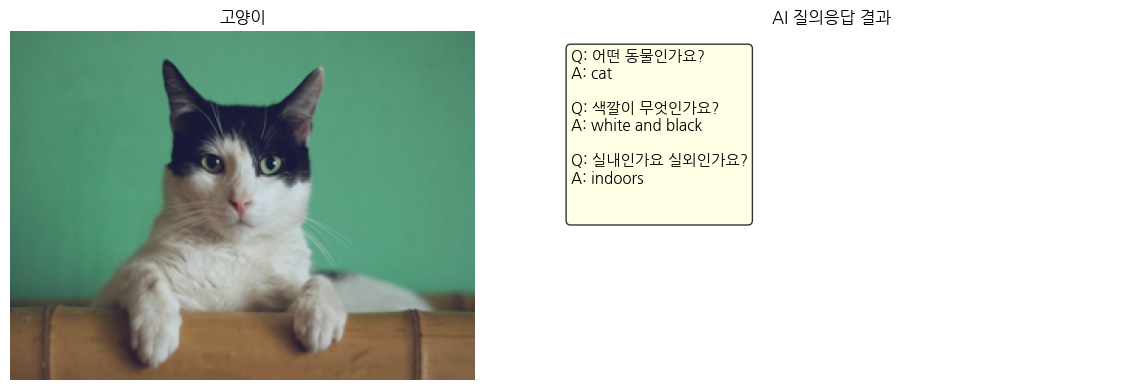


📷 [도시 풍경] 이미지에 대한 질의응답:
  Q: 무엇이 보이나요?
  A (영어): city

  Q: 나무가 있나요?
  A (영어): no

  Q: 낮인가요 밤인가요?
  A (영어): day



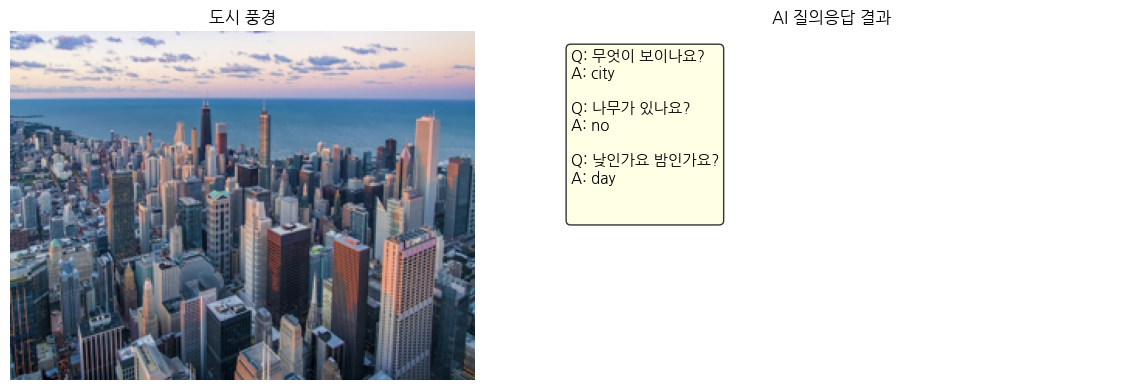


📷 [음식] 이미지에 대한 질의응답:
  Q: 어떤 종류의 음식인가요?
  A (영어): salad

  Q: 음식 색깔은?
  A (영어): green red yellow and white

  Q: 그릇에 담겨있나요?
  A (영어): bowl



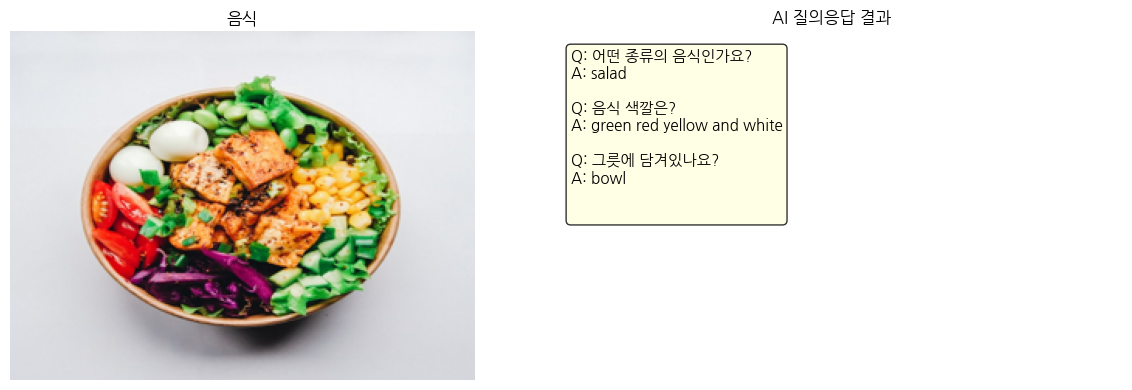


✅ VQA: AI가 이미지를 이해하고 질문에 직접 답변합니다!


In [10]:
def ask_image(image, question):
    """이미지에 대해 영어로 질문하고 답변을 받습니다"""
    inputs = vqa_processor(image, question, return_tensors="pt").to(device)
    with torch.no_grad():
        output = vqa_model.generate(**inputs, max_length=20)
    answer = vqa_processor.decode(output[0], skip_special_tokens=True)
    return answer

# 이미지별 질문 목록
image_questions = {
    '고양이': [
        ("What animal is in the image?", "어떤 동물인가요?"),
        ("What color is the animal?", "색깔이 무엇인가요?"),
        ("Is the animal indoors or outdoors?", "실내인가요 실외인가요?"),
    ],
    '도시 풍경': [
        ("What is shown in this image?", "무엇이 보이나요?"),
        ("Are there trees in the image?", "나무가 있나요?"),
        ("Is it day or night?", "낮인가요 밤인가요?"),
    ],
    '음식': [
        ("What type of food is this?", "어떤 종류의 음식인가요?"),
        ("What color is the food?", "음식 색깔은?"),
        ("Is the food in a bowl or plate?", "그릇에 담겨있나요?"),
    ]
}

print('='*60)
print('VQA 실습: AI에게 이미지를 보고 질문에 답하게 합니다!')
print('='*60)

for img_name, img in images.items():
    if img_name not in image_questions:
        continue

    print(f'\n📷 [{img_name}] 이미지에 대한 질의응답:')
    questions = image_questions[img_name]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title(img_name, fontsize=12)
    axes[0].axis('off')

    qa_text = ''
    for eng_q, kor_q in questions:
        answer = ask_image(img, eng_q)
        print(f'  Q: {kor_q}')
        print(f'  A (영어): {answer}')
        print()
        qa_text += f'Q: {kor_q}\nA: {answer}\n\n'

    axes[1].text(0.05, 0.95, qa_text, transform=axes[1].transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1].set_title('AI 질의응답 결과', fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

print('\n✅ VQA: AI가 이미지를 이해하고 질문에 직접 답변합니다!')

나만의 이미지 VQA 결과:
Q: 주요 피사체가 무엇인가요?  →  A: cat
Q: 색깔이 무엇인가요?  →  A: white
Q: 몇 개/마리인가요?  →  A: 1


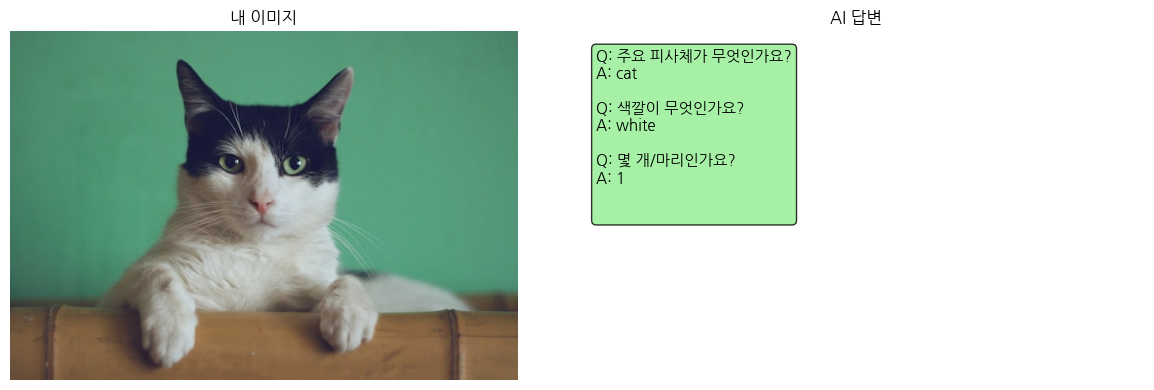

In [11]:
# 직접 해보기: 나만의 이미지로 질문하기
# ✏️ 아래 URL과 질문을 바꿔보세요!

my_url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=640&q=80"
my_questions_en = [
    "What is the main subject?",
    "What color is it?",
    "How many are there?"
]
my_questions_ko = [
    "주요 피사체가 무엇인가요?",
    "색깔이 무엇인가요?",
    "몇 개/마리인가요?"
]

my_img = load_image_from_url(my_url)

print('나만의 이미지 VQA 결과:')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(my_img)
ax1.set_title('내 이미지', fontsize=12)
ax1.axis('off')

qa_text = ''
for en_q, ko_q in zip(my_questions_en, my_questions_ko):
    ans = ask_image(my_img, en_q)
    print(f'Q: {ko_q}  →  A: {ans}')
    qa_text += f'Q: {ko_q}\nA: {ans}\n\n'

ax2.text(0.05, 0.95, qa_text, transform=ax2.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax2.set_title('AI 답변', fontsize=12)
ax2.axis('off')
plt.tight_layout()
plt.show()

---

# 6️⃣ VLM의 핵심 원리 시각화

## 이미지-텍스트 유사도 히트맵

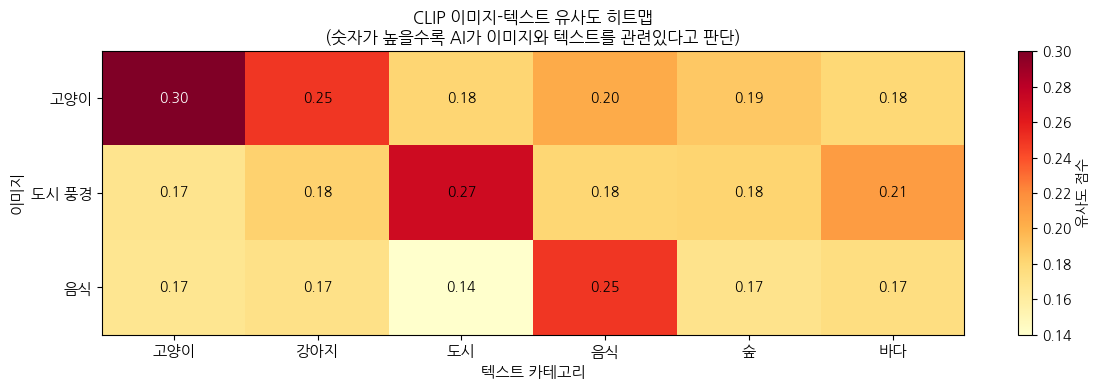

✅ CLIP은 이미지와 관련 텍스트를 높은 점수로, 무관한 것을 낮은 점수로 매깁니다!


In [12]:
# CLIP 임베딩 공간 시각화
# 이미지와 텍스트가 같은 공간에 배치되는 원리를 눈으로 확인!

text_descriptions = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a city skyline",
    "a photo of delicious food",
    "a photo of a forest",
    "a photo of the ocean",
]
text_ko = ["고양이", "강아지", "도시", "음식", "숲", "바다"]

img_list = list(images.values())
img_names = list(images.keys())

def extract_features(tensor_or_output):
    """텐서 또는 모델 출력 객체에서 특징 벡터를 추출"""
    if isinstance(tensor_or_output, torch.Tensor):
        return tensor_or_output
    # BaseModelOutputWithPooling 등 객체 처리
    for attr in ['image_embeds', 'text_embeds', 'pooler_output', 'last_hidden_state']:
        if hasattr(tensor_or_output, attr):
            val = getattr(tensor_or_output, attr)
            if val is not None:
                # last_hidden_state면 CLS 토큰(첫 번째)만 사용
                return val[:, 0] if val.dim() == 3 else val
    raise ValueError(f"특징 벡터를 찾을 수 없습니다: {type(tensor_or_output)}")

# 이미지 특징 추출
image_features_list = []
for img in img_list:
    img_input = clip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        raw = clip_model.get_image_features(pixel_values=img_input['pixel_values'])
        img_feat = extract_features(raw)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    image_features_list.append(img_feat)

# 텍스트 특징 추출
text_inputs = clip_processor(text=text_descriptions, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    raw = clip_model.get_text_features(
        input_ids=text_inputs['input_ids'],
        attention_mask=text_inputs['attention_mask']
    )
    text_features = extract_features(raw)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

image_features = torch.cat(image_features_list, dim=0)
similarity_matrix = (image_features @ text_features.T).cpu().numpy()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(similarity_matrix, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(text_ko)))
ax.set_xticklabels(text_ko, fontsize=11)
ax.set_yticks(range(len(img_names)))
ax.set_yticklabels(img_names, fontsize=11)

for i in range(len(img_names)):
    for j in range(len(text_ko)):
        ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='black' if similarity_matrix[i, j] < 0.3 else 'white')

plt.colorbar(im, ax=ax, label='유사도 점수')
ax.set_title('CLIP 이미지-텍스트 유사도 히트맵\n(숫자가 높을수록 AI가 이미지와 텍스트를 관련있다고 판단)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('텍스트 카테고리', fontsize=11)
ax.set_ylabel('이미지', fontsize=11)
plt.tight_layout()
plt.show()

print('✅ CLIP은 이미지와 관련 텍스트를 높은 점수로, 무관한 것을 낮은 점수로 매깁니다!')

---

# 7️⃣ 최신 VLM 트렌드 및 정리

## 📖 VLM의 발전 방향

### 기술 발전 흐름

```
2021: CLIP ──────→ 이미지-텍스트 연결의 시작
2022: BLIP ──────→ 이미지 캡셔닝, VQA 가능
2023: GPT-4V ────→ ChatGPT가 이미지를 이해
2023: LLaVA ─────→ 오픈소스 VLM의 등장
2024: Gemini ────→ 텍스트+이미지+음성+동영상 통합
2024: Claude 3 ──→ 멀티모달 추론 능력 강화
2025+: ??  ──────→ 더욱 발전 중!
```

### 군사/안보 분야 활용 가능성

| 분야 | 활용 예시 |
|------|----------|
| 위성 영상 분석 | "이 위성 사진에서 군사 시설을 찾아줘" |
| 드론 영상 처리 | 실시간 표적 식별 및 분류 |
| 문서 분석 | 외국어 문서 사진을 읽고 번역 |
| 의무 지원 | 의료 영상 분석 보조 |
| 훈련 시뮬레이션 | 가상 환경 이미지 생성 |

## 핵심 요약

1. **VLM = 이미지 + 언어를 함께 이해하는 AI**
2. **CLIP**: 이미지-텍스트를 같은 공간에 배치하여 유사도 비교
3. **BLIP**: 이미지를 보고 설명을 생성하거나 질문에 답변
4. **GPT-4V / Gemini**: 사람처럼 이미지를 보고 대화 가능

### 핵심 원리 한 문장

> **"이미지와 텍스트를 같은 숫자 공간에 배치하여 비교·이해하는 기술"**